# Repository guide: Training curves; uses recorded values embedded in plotting cells

Original code and recorded outputs retained. Read ../../docs/RUNNING.md before execution. Plot values are embedded, not dynamically read from the CSV; compare with the saved training history.


In [ ]:
# Find saved Trainer state files
from google.colab import drive
drive.mount("/content/drive")

!find /content/drive/MyDrive -name "trainer_state.json" 2>/dev/null

Mounted at /content/drive


In [ ]:
# Check the saved training history
from pathlib import Path

history_path = Path(
    "/content/drive/Othercomputers/My MacBook Pro/"
    "tarifit_asr_tfm/results/"
    "mms_1b_tarifit_v1_2_half_bible_specaug/"
    "training_history.csv"
)

print("Exists:", history_path.exists())
print(history_path)

Exists: True
/content/drive/Othercomputers/My MacBook Pro/tarifit_asr_tfm/results/mms_1b_tarifit_v1_2_half_bible_specaug/training_history.csv


In [ ]:
# Load the saved MMS training history
import pandas as pd

history = pd.read_csv(history_path)
display(history)

,epoch,training_loss,validation_loss,WER,CER
0,1.0,0.7440,2.849272,0.894558,0.441032
1,2.0,0.6581,3.050890,0.877551,0.438138
2,3.0,0.6180,3.075217,0.849915,0.427526
3,4.0,0.5689,3.032704,0.847364,0.424954


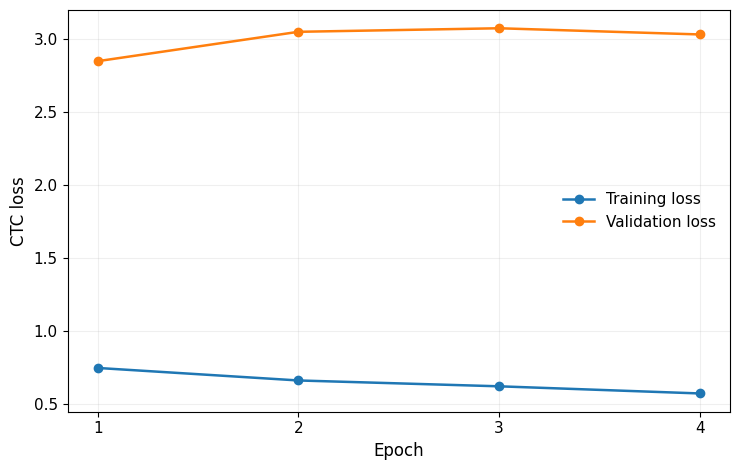

In [ ]:
# Plot MMS training and validation loss
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4]
train_loss = [0.7440, 0.6581, 0.6180, 0.5689]
val_loss = [2.849272, 3.050890, 3.075217, 3.032704]

plt.figure(figsize=(7.5, 4.8))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    linewidth=1.8,
    label="Training loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    linewidth=1.8,
    label="Validation loss"
)

plt.xlabel("Epoch", fontname="Times New Roman", fontsize=12)
plt.ylabel("CTC loss", fontname="Times New Roman", fontsize=12)

plt.xticks(
    epochs,
    fontname="Times New Roman",
    fontsize=11
)

plt.yticks(
    fontname="Times New Roman",
    fontsize=11
)

plt.legend(
    prop={"family": "Times New Roman", "size": 11},
    frameon=False
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/mms_half_bible_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

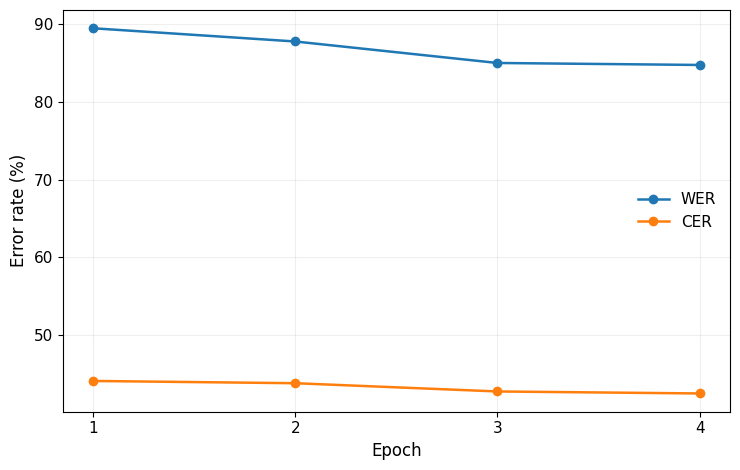

In [ ]:
# Plot validation WER and CER across epochs
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4]
wer = [89.4558, 87.7551, 84.9915, 84.7364]
cer = [44.1032, 43.8138, 42.7526, 42.4954]

plt.figure(figsize=(7.5, 4.8))

plt.plot(
    epochs,
    wer,
    marker="o",
    linewidth=1.8,
    label="WER"
)

plt.plot(
    epochs,
    cer,
    marker="o",
    linewidth=1.8,
    label="CER"
)

plt.xlabel("Epoch", fontname="Times New Roman", fontsize=12)
plt.ylabel("Error rate (%)", fontname="Times New Roman", fontsize=12)

plt.xticks(
    epochs,
    fontname="Times New Roman",
    fontsize=11
)

plt.yticks(
    fontname="Times New Roman",
    fontsize=11
)

plt.legend(
    prop={"family": "Times New Roman", "size": 11},
    frameon=False
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/mms_half_bible_validation_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

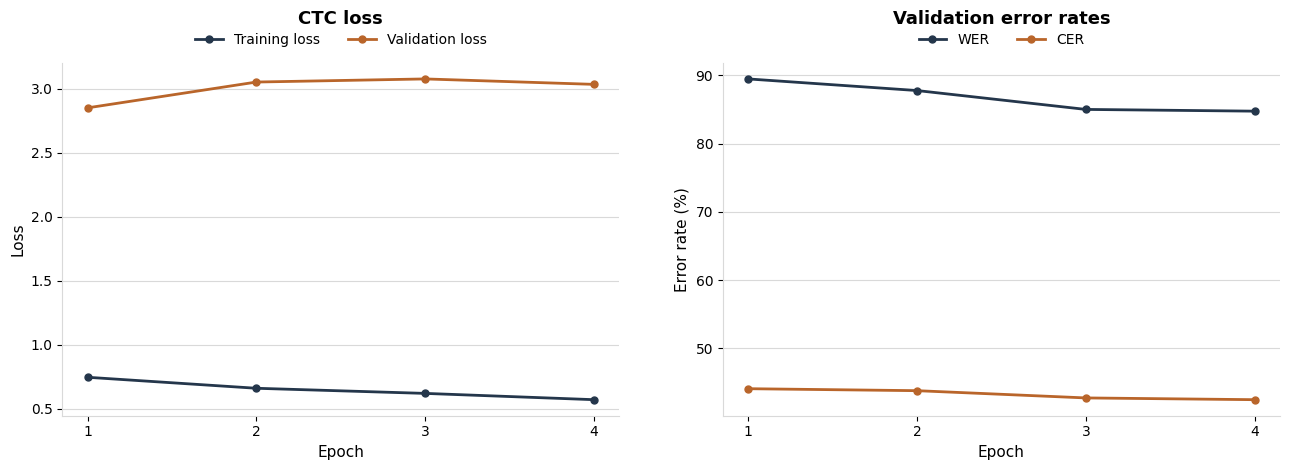

In [ ]:
# Create thesis-style two-panel training figure
import matplotlib.pyplot as plt

# Data
epochs = [1, 2, 3, 4]

train_loss = [0.7440, 0.6581, 0.6180, 0.5689]
val_loss   = [2.849272, 3.050890, 3.075217, 3.032704]

wer = [89.4558, 87.7551, 84.9915, 84.7364]
cer = [44.1032, 43.8138, 42.7526, 42.4954]

# Thesis colors
navy = "#24364B"
terracotta = "#B9652A"
grid_color = "#D9D9D9"

plt.rcParams["font.family"] = "Times New Roman"

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 4.8)
)

# --------------------------------------------------
# Panel (a): Training and validation loss
# --------------------------------------------------
ax = axes[0]

ax.plot(
    epochs,
    train_loss,
    linewidth=2,
    marker="o",
    markersize=5,
    label="Training loss",
    color=navy
)

ax.plot(
    epochs,
    val_loss,
    linewidth=2,
    marker="o",
    markersize=5,
    label="Validation loss",
    color=terracotta
)

ax.set_title(
    "CTC loss",
    fontsize=13,
    fontweight="bold",
    pad=28
)

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)

ax.set_xticks(epochs)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=10
)

ax.grid(
    axis="y",
    color=grid_color,
    linewidth=0.8
)

ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(grid_color)
ax.spines["bottom"].set_color(grid_color)


# --------------------------------------------------
# Panel (b): Validation WER and CER
# --------------------------------------------------
ax = axes[1]

ax.plot(
    epochs,
    wer,
    linewidth=2,
    marker="o",
    markersize=5,
    label="WER",
    color=navy
)

ax.plot(
    epochs,
    cer,
    linewidth=2,
    marker="o",
    markersize=5,
    label="CER",
    color=terracotta
)

ax.set_title(
    "Validation error rates",
    fontsize=13,
    fontweight="bold",
    pad=28
)

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Error rate (%)", fontsize=11)

ax.set_xticks(epochs)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=10
)

ax.grid(
    axis="y",
    color=grid_color,
    linewidth=0.8
)

ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(grid_color)
ax.spines["bottom"].set_color(grid_color)

# Overall spacing
plt.tight_layout(w_pad=4)

# Save high-resolution version
plt.savefig(
    "/content/mms_training_dynamics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()